# TomatoScan — Exploration MobileNetV2

Notebook d'exploration pour valider le pipeline d'entraînement sur le dataset PlantVillage.

**Objectif** : Transfer learning rapide (5 epochs) avec MobileNetV2 pour vérifier que tout fonctionne correctement avant le vrai entraînement.

**Hardware cible** : Mac Apple Silicon — `tensorflow-macos` + `tensorflow-metal`

**Dataset** : PlantVillage — 10 classes Tomato uniquement (Pepper et Potato ignorés)

**Architecture** : MobileNetV2 (ImageNet) → GlobalAveragePooling2D → Dense(128) → Dropout(0.2) → Dense(10, softmax)

---
*Projet de diplôme DevIA Simplon — Sulivan Moreau*

In [1]:
# ─── Cellule 1 : Imports et vérification du matériel ───────────────────────
import os
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import tensorflow as tf
import mlflow
import mlflow.keras
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

print(f"TensorFlow version : {tf.__version__}")
print(f"MLflow version     : {mlflow.__version__}")
print(f"NumPy version      : {np.__version__}")

# ── Vérification du GPU Apple Silicon (Metal Performance Shaders) ──────────
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"\n✓ GPU Apple Silicon détecté ({len(gpus)} device(s)) :")
    for gpu in gpus:
        print(f"  {gpu}")
        # Allocation mémoire dynamique pour éviter les OOM
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("\n⚠ Aucun GPU détecté — entraînement sur CPU (beaucoup plus lent)")
    print("  Vérifiez que tensorflow-metal est installé : uv pip install tensorflow-metal")

# Reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

Matplotlib is building the font cache; this may take a moment.


TensorFlow version : 2.16.2
MLflow version     : 3.14.0
NumPy version      : 1.26.4

✓ GPU Apple Silicon détecté (1 device(s)) :
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [2]:
# ─── Cellule 2 : Chargement et filtrage du dataset PlantVillage ─────────────

# Résolution du chemin du dataset depuis la racine du projet
# Le notebook se trouve dans notebooks/, donc on remonte d'un niveau
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATASET_PATH = PROJECT_ROOT / "PlantVillage" / "PlantVillage"

print(f"Racine du projet  : {PROJECT_ROOT}")
print(f"Chemin du dataset : {DATASET_PATH}")

# Vérification de l'existence du dataset
if not DATASET_PATH.exists():
    raise FileNotFoundError(
        f"Dataset introuvable : {DATASET_PATH}\n"
        "Placez PlantVillage/PlantVillage/ à la racine du projet."
    )

# ── Classes Tomato à conserver (Pepper et Potato sont ignorés) ─────────────
CLASSES_TOMATES = [
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato_healthy",
]

# Vérifier que les dossiers existent réellement dans le dataset
classes_disponibles = {d.name for d in DATASET_PATH.iterdir() if d.is_dir()}
classes_valides = [c for c in CLASSES_TOMATES if c in classes_disponibles]
classes_manquantes = [c for c in CLASSES_TOMATES if c not in classes_disponibles]

print(f"\nClasses Tomato trouvées : {len(classes_valides)}/10")
if classes_manquantes:
    print(f"⚠ Classes manquantes dans le dataset : {classes_manquantes}")

# ── Paramètres du chargement ───────────────────────────────────────────────
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Chargement train (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    class_names=classes_valides,   # filtre implicite : seules les classes listées
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

# Chargement validation (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    class_names=classes_valides,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

# Noms de classes dans l'ordre assigné par TensorFlow
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"\n{NUM_CLASSES} classes chargées (ordre alphanumérique TF) :")
for i, name in enumerate(class_names):
    print(f"  {i:2d} — {name}")

# ── Compter les images par classe ──────────────────────────────────────────
print("\nNombre d'images par classe :")
total = 0
for cls in class_names:
    cls_path = DATASET_PATH / cls
    n = sum(1 for f in cls_path.iterdir()
            if f.suffix.lower() in (".jpg", ".jpeg", ".png"))
    total += n
    print(f"  {cls:<55s} : {n:5d} images")
print(f"  {'TOTAL':<55s} : {total:5d} images")

Racine du projet  : /Users/sulivan/Documents/PROJET/TomatoScan
Chemin du dataset : /Users/sulivan/Documents/PROJET/TomatoScan/PlantVillage/PlantVillage

Classes Tomato trouvées : 10/10
Found 16011 files belonging to 10 classes.
Using 12809 files for training.


2026-06-23 15:41:06.180315: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-06-23 15:41:06.180351: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-06-23 15:41:06.180360: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-06-23 15:41:06.180393: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-23 15:41:06.180404: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 16011 files belonging to 10 classes.
Using 3202 files for validation.

10 classes chargées (ordre alphanumérique TF) :
   0 — Tomato_Bacterial_spot
   1 — Tomato_Early_blight
   2 — Tomato_Late_blight
   3 — Tomato_Leaf_Mold
   4 — Tomato_Septoria_leaf_spot
   5 — Tomato_Spider_mites_Two_spotted_spider_mite
   6 — Tomato__Target_Spot
   7 — Tomato__Tomato_YellowLeaf__Curl_Virus
   8 — Tomato__Tomato_mosaic_virus
   9 — Tomato_healthy

Nombre d'images par classe :
  Tomato_Bacterial_spot                                   :  2127 images
  Tomato_Early_blight                                     :  1000 images
  Tomato_Late_blight                                      :  1909 images
  Tomato_Leaf_Mold                                        :   952 images
  Tomato_Septoria_leaf_spot                               :  1771 images
  Tomato_Spider_mites_Two_spotted_spider_mite             :  1676 images
  Tomato__Target_Spot                                     :  1404 images
  Tomato__Tomat

Pipeline de données configuré :
  Train  — normalisation (÷255) + flip horizontal + rotation ±10 %
  Val    — normalisation uniquement
  Prefetch AUTOTUNE activé


2026-06-23 15:41:06.790402: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-06-23 15:41:06.963831: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


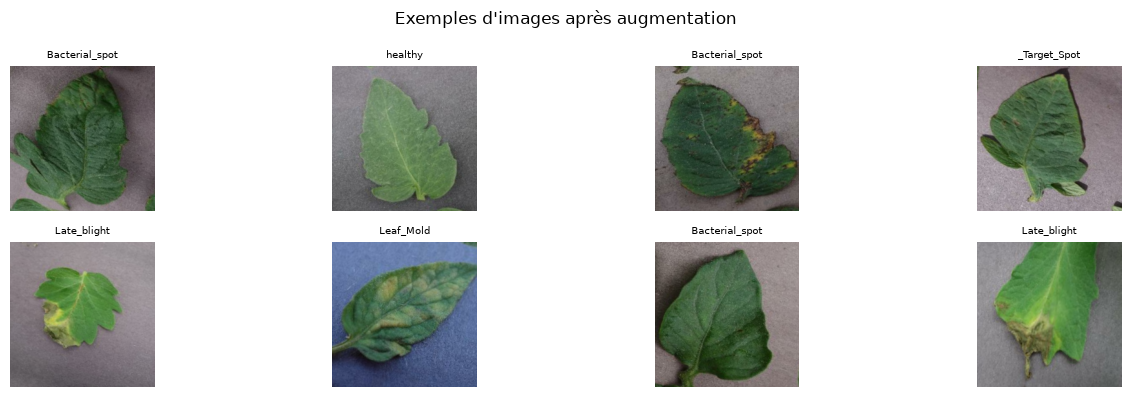

In [3]:
# ─── Cellule 3 : Prétraitement et augmentation des données ──────────────────

AUTOTUNE = tf.data.AUTOTUNE

# Couche de normalisation : pixels 0-255 → 0.0-1.0
normalisation = tf.keras.layers.Rescaling(1.0 / 255)

# Augmentation légère appliquée uniquement au jeu d'entraînement
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
], name="augmentation_legere")


def preprocess_train(images, labels):
    """Normalisation + augmentation pour le train."""
    images = normalisation(images)
    images = augmentation(images, training=True)
    return images, labels


def preprocess_val(images, labels):
    """Normalisation seule pour la validation (pas d'augmentation)."""
    return normalisation(images), labels


# Pipeline optimisé : map + prefetch (cache optionnel si assez de RAM)
train_ds = (
    train_ds
    .map(preprocess_train, num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

val_ds = (
    val_ds
    .map(preprocess_val, num_parallel_calls=AUTOTUNE)
    .prefetch(buffer_size=AUTOTUNE)
)

print("Pipeline de données configuré :")
print("  Train  — normalisation (÷255) + flip horizontal + rotation ±10 %")
print("  Val    — normalisation uniquement")
print("  Prefetch AUTOTUNE activé")

# ── Visualisation d'un batch après augmentation ────────────────────────────
plt.figure(figsize=(14, 4))
for images, labels in train_ds.take(1):
    for i in range(min(8, images.shape[0])):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]].replace("Tomato_", "").replace("Tomato__", ""),
                  fontsize=7)
        plt.axis("off")
plt.suptitle("Exemples d'images après augmentation", fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
# ─── Cellule 4 : Modèle MobileNetV2 Transfer Learning ──────────────────────

# Charger MobileNetV2 pré-entraîné ImageNet — on retire la tête de classification
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
)

# Geler toutes les couches de la base (feature extraction pure)
base_model.trainable = False
couches_gelees = sum(1 for l in base_model.layers if not l.trainable)
print(f"Base MobileNetV2 : {len(base_model.layers)} couches — {couches_gelees} gelées")

# ── Construction de la tête de classification ──────────────────────────────
inputs  = tf.keras.Input(shape=(*IMAGE_SIZE, 3), name="image_input")
x       = base_model(inputs, training=False)           # extraction features
x       = tf.keras.layers.GlobalAveragePooling2D()(x)  # aplatissement spatial
x       = tf.keras.layers.Dense(128, activation="relu", name="dense_128")(x)
x       = tf.keras.layers.Dropout(0.2, name="dropout_02")(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name="classification")(x)

model = tf.keras.Model(inputs, outputs, name="tomatoscan_mobilenetv2")

# Compilation
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

# Compter les paramètres entraînables
params_entrainables = sum(
    tf.size(v).numpy() for v in model.trainable_variables
)
params_totaux = sum(
    tf.size(v).numpy() for v in model.variables
)
print(f"\nParamètres entraînables : {params_entrainables:>10,}")
print(f"Paramètres totaux       : {params_totaux:>10,}")
print(f"Ratio entraînable       : {params_entrainables/params_totaux*100:.1f} %")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base MobileNetV2 : 154 couches — 154 gelées


Model: "tomatoscan_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_02 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification (Dense)          │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Paramètres entraînables :    165,258
Paramètres totaux       :  2,423,244
Ratio entraînable       : 6.8 %


2026/06/23 15:41:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/23 15:41:12 INFO mlflow.store.db.utils: Updating database tables
2026/06/23 15:41:13 INFO mlflow.tracking.fluent: Experiment with name 'tomatoscan_exploration' does not exist. Creating a new experiment.


MLflow run démarré : 5656cd307b454370ae0dcd8cf3947dd3
Epoch 1/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.6735 - loss: 1.0447 - val_accuracy: 0.8401 - val_loss: 0.4641
Epoch 2/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.8085 - loss: 0.5953 - val_accuracy: 0.8688 - val_loss: 0.3980
Epoch 3/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.8367 - loss: 0.4915 - val_accuracy: 0.8460 - val_loss: 0.4384
Epoch 4/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 38s 95ms/step - accuracy: 0.8538 - loss: 0.4457 - val_accuracy: 0.8795 - val_loss: 0.3639
Epoch 5/5
401/401 ━━━━━━━━━━━━━━━━━━━━ 38s 96ms/step - accuracy: 0.8692 - loss: 0.4020 - val_accuracy: 0.8863 - val_loss: 0.3278
Restoring model weights from the end of the best epoch: 5.

✓ Entraînement terminé — 5 epochs effectuées


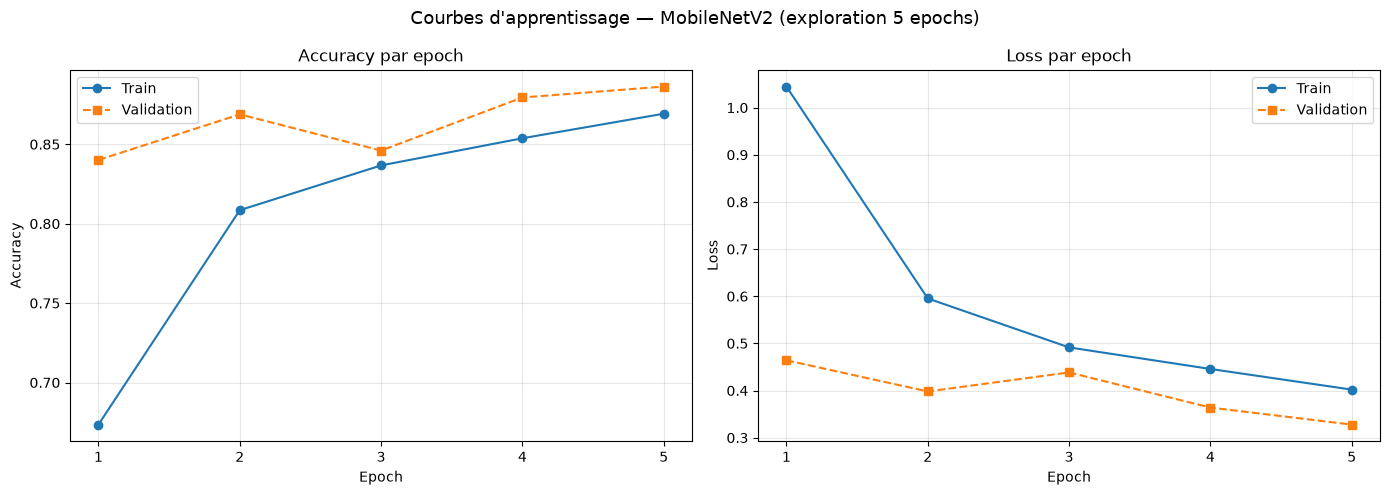

In [5]:
# ─── Cellule 5 : Entraînement rapide avec suivi MLflow ─────────────────────

EPOCHS = 5  # entraînement minimal pour valider le pipeline

# Hyperparamètres à logger
params_mlflow = {
    "epochs":          EPOCHS,
    "batch_size":      BATCH_SIZE,
    "image_size":      f"{IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}",
    "num_classes":     NUM_CLASSES,
    "base_model":      "MobileNetV2",
    "base_trainable":  False,
    "optimizer":       "adam",
    "learning_rate":   1e-3,
    "dense_units":     128,
    "dropout":         0.2,
    "loss":            "sparse_categorical_crossentropy",
}


class MLflowCallback(tf.keras.callbacks.Callback):
    """Callback Keras qui logue les métriques dans MLflow à chaque epoch."""

    def on_epoch_end(self, epoch, logs=None):
        if logs:
            mlflow.log_metrics(
                {k: float(v) for k, v in logs.items()},
                step=epoch + 1,
            )


# Early stopping de sécurité (ne devrait pas se déclencher sur 5 epochs)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

# ── Lancement de l'expérience MLflow ──────────────────────────────────────
mlflow.set_experiment("tomatoscan_exploration")

with mlflow.start_run(run_name="mobilenetv2_exploration") as run:
    RUN_ID = run.info.run_id
    print(f"MLflow run démarré : {RUN_ID}")

    mlflow.log_params(params_mlflow)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=[MLflowCallback(), early_stopping],
        verbose=1,
    )

print(f"\n✓ Entraînement terminé — {len(history.epoch)} epochs effectuées")

# ── Courbes d'apprentissage ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history.history["accuracy"]) + 1)

axes[0].plot(epochs_range, history.history["accuracy"],    "o-", label="Train")
axes[0].plot(epochs_range, history.history["val_accuracy"], "s--", label="Validation")
axes[0].set_title("Accuracy par epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history["loss"],     "o-", label="Train")
axes[1].plot(epochs_range, history.history["val_loss"], "s--", label="Validation")
axes[1].set_title("Loss par epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage — MobileNetV2 (exploration 5 epochs)", fontsize=13)
plt.tight_layout()
plt.show()

Accuracy validation : 0.8863  (88.63 %)
Loss validation     : 0.3278


2026-06-23 15:44:48.090852: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


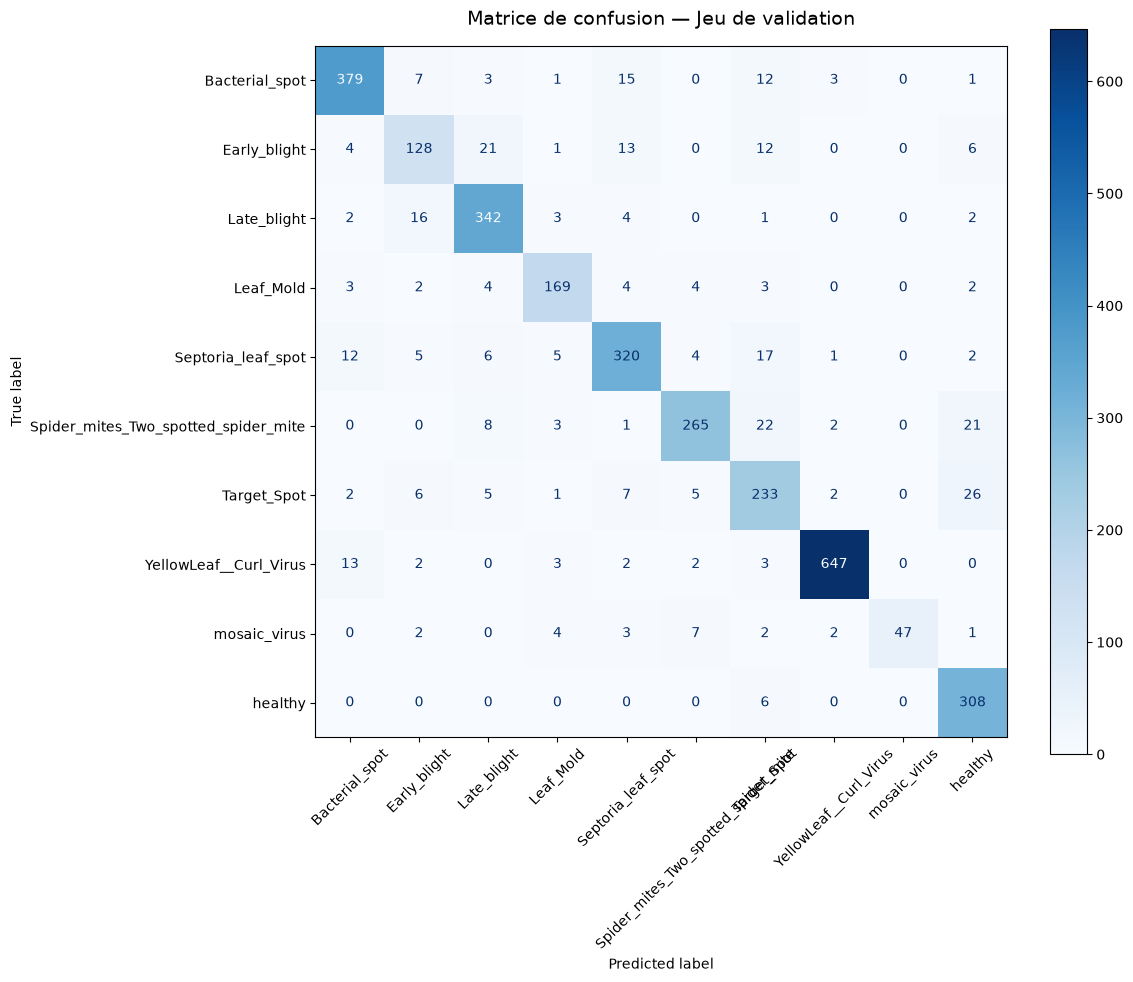

2026/06/23 15:44:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/23 15:44:48 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2026/06/23 15:44:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.



✓ Modèle et métriques finales loggés dans MLflow (run : 5656cd307b454370ae0dcd8cf3947dd3)


In [6]:
# ─── Cellule 6 : Évaluation et matrice de confusion ────────────────────────

# Évaluation finale sur le jeu de validation
val_loss, val_accuracy = model.evaluate(val_ds, verbose=0)
print(f"Accuracy validation : {val_accuracy:.4f}  ({val_accuracy * 100:.2f} %)")
print(f"Loss validation     : {val_loss:.4f}")

# ── Collecte des prédictions pour la matrice de confusion ─────────────────
y_true, y_pred = [], []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Étiquettes courtes pour la lisibilité de la matrice
labels_courts = [
    name.replace("Tomato__", "").replace("Tomato_", "")
    for name in class_names
]

# Affichage de la matrice de confusion
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_courts)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
ax.set_title("Matrice de confusion — Jeu de validation", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# ── Logger le modèle et les métriques finales dans MLflow ─────────────────
with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metric("final_val_accuracy", val_accuracy)
    mlflow.log_metric("final_val_loss",     val_loss)
    mlflow.keras.log_model(model, artifact_path="mobilenetv2_exploration")

print(f"\n✓ Modèle et métriques finales loggés dans MLflow (run : {RUN_ID})")

In [7]:
# ─── Cellule 7 : Sauvegarde du modèle ──────────────────────────────────────

# Dossier de sauvegarde à la racine du projet
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODELS_DIR / "mobilenetv2_exploration.keras"

# Sauvegarde au format .keras (format natif recommandé depuis TF 2.12)
model.save(MODEL_PATH)
taille_mo = MODEL_PATH.stat().st_size / (1024 ** 2)
print(f"✓ Modèle sauvegardé : {MODEL_PATH}")
print(f"  Taille             : {taille_mo:.1f} Mo")

# Vérification : rechargement et évaluation rapide
model_reloaded = tf.keras.models.load_model(MODEL_PATH)
_, acc_verif = model_reloaded.evaluate(val_ds, verbose=0)
print(f"✓ Vérification rechargement — Accuracy : {acc_verif:.4f}")

# ── Récapitulatif final ────────────────────────────────────────────────────
print()
print("═" * 58)
print(" RÉCAPITULATIF — Exploration MobileNetV2")
print("═" * 58)
print(f"  Dataset        : PlantVillage ({NUM_CLASSES} classes Tomato)")
print(f"  Architecture   : MobileNetV2 + Dense(128) + Dropout(0.2)")
print(f"  Epochs         : {len(history.epoch)}")
print(f"  Accuracy val   : {val_accuracy:.4f}  ({val_accuracy * 100:.2f} %)")
print(f"  Loss val       : {val_loss:.4f}")
print(f"  Modèle         : {MODEL_PATH.name}")
print(f"  MLflow run     : {RUN_ID}")
print("═" * 58)

✓ Modèle sauvegardé : /Users/sulivan/Documents/PROJET/TomatoScan/models/mobilenetv2_exploration.keras
  Taille             : 11.1 Mo
✓ Vérification rechargement — Accuracy : 0.8863

══════════════════════════════════════════════════════════
 RÉCAPITULATIF — Exploration MobileNetV2
══════════════════════════════════════════════════════════
  Dataset        : PlantVillage (10 classes Tomato)
  Architecture   : MobileNetV2 + Dense(128) + Dropout(0.2)
  Epochs         : 5
  Accuracy val   : 0.8863  (88.63 %)
  Loss val       : 0.3278
  Modèle         : mobilenetv2_exploration.keras
  MLflow run     : 5656cd307b454370ae0dcd8cf3947dd3
══════════════════════════════════════════════════════════
